# Анализ токенов: диалог-стоимость генерации эвристик

Сравнение трех подходов по объему входных и выходных токенов:
- **DSL** - полное JSON-описание + системный промпт -> `solve_scheduling`
- **Text** - текстовый промпт -> `solve_scheduling`
- **Skeleton** - краткое JSON-описание + системный промпт (с описанием каркаса) -> `select_job_fn + allocate_fn`

**Ключевые метрики диалог-стоимости:**
- `Prompt Tokens` - объем входного контекста (DSL/текст + системный промпт)
- `Completion Tokens` - объем генерируемого кода (главный показатель нагрузки)
- `Total Tokens` - суммарная стоимость одного запроса

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Загрузка данных

In [2]:
import json
import pandas as pd
from pathlib import Path

EXP_DIR = Path('../../experiments')

CASE_NAMES = {1: 'Case 1\n(RCPSP)', 2: 'Case 2\n(Single Machine)',
              3: 'Case 3\n(RCPSP+NRR)', 4: 'Case 4\n(Conditional)',
              5: 'Case 5\n(RCMPSP)'}
CASE_NAMES_FULL = {1: 'Case 1 (RCPSP)', 2: 'Case 2 (Single Machine)',
                   3: 'Case 3 (RCPSP+NRR)', 4: 'Case 4 (Conditional RCPSP)',
                   5: 'Case 5 (RCMPSP)'}
colors = {'DSL': '#4C72B0', 'Text': '#DD8452', 'Skeleton': '#55A868'}

def load_approach(approach_dir: Path, approach_name: str) -> list[dict]:
    result_rows = []
    if not approach_dir.exists():
        print(f"  [SKIP] Папка не найдена: {approach_dir}")
        return result_rows

    files = sorted(approach_dir.glob('experiment_results_Case*.xlsx'))
    print(f"  [{approach_name}] Файлов: {len(files)} в {approach_dir}")

    for f in files:
        case_num = None
        for n in range(1, 6):
            if f'Case{n}' in f.stem:
                case_num = n
                break
        if case_num is None:
            continue

        df_case = pd.read_excel(f)
        # Оставляем только успешные runs
        df_ok = df_case[df_case['Статус'] == 'OK']
        added = 0
        for _, run in df_ok.iterrows():
            result_rows.append({
                'Подход': approach_name,
                'Кейс': CASE_NAMES_FULL[case_num],
                'Кейс_short': CASE_NAMES[case_num],
                'Run': run['Run'],
                'Prompt':  run['Prompt Tokens'],
                'Completion': run['Completion Tokens'],
                'Total': run['Total Tokens'],
            })
            added += 1
        print(f"    {f.name}: {added} rows (из {len(df_case)})")

    return result_rows

rows = []
rows += load_approach(EXP_DIR / 'experiments_dsl', 'DSL')
rows += load_approach(EXP_DIR / 'experiment text', 'Text')
rows += load_approach(EXP_DIR / 'experiment_skeleton', 'Skeleton')

df = pd.DataFrame(rows)
print(f"\nВсего записей: {len(df)}")
print(f"По подходам: {df['Подход'].value_counts().to_dict()}")
df.head()

  [DSL] Файлов: 5 в ..\..\experiments\experiments_dsl
    experiment_results_Case1.xlsx: 10 rows (из 10)
    experiment_results_Case2.xlsx: 10 rows (из 10)
    experiment_results_Case3.xlsx: 10 rows (из 10)
    experiment_results_Case4.xlsx: 10 rows (из 10)
    experiment_results_Case5.xlsx: 10 rows (из 10)
  [Text] Файлов: 5 в ..\..\experiments\experiment text
    experiment_results_Case1.xlsx: 10 rows (из 10)
    experiment_results_Case2.xlsx: 10 rows (из 10)
    experiment_results_Case3.xlsx: 10 rows (из 10)
    experiment_results_Case4.xlsx: 10 rows (из 10)
    experiment_results_Case5.xlsx: 10 rows (из 10)
  [Skeleton] Файлов: 5 в ..\..\experiments\experiment_skeleton
    experiment_results_Case1.xlsx: 10 rows (из 10)
    experiment_results_Case2.xlsx: 10 rows (из 10)
    experiment_results_Case3.xlsx: 8 rows (из 10)
    experiment_results_Case4.xlsx: 10 rows (из 10)
    experiment_results_Case5.xlsx: 10 rows (из 10)

Всего записей: 148
По подходам: {'DSL': 50, 'Text': 50, 'Skelet

,Подход,Кейс,Кейс_short,Run,Prompt,Completion,Total
0,DSL,Case 1 (RCPSP),Case 1\n(RCPSP),1,693.0,3175.0,3868.0
1,DSL,Case 1 (RCPSP),Case 1\n(RCPSP),2,693.0,4120.0,4813.0
2,DSL,Case 1 (RCPSP),Case 1\n(RCPSP),3,693.0,2643.0,3336.0
3,DSL,Case 1 (RCPSP),Case 1\n(RCPSP),4,693.0,2689.0,3382.0
4,DSL,Case 1 (RCPSP),Case 1\n(RCPSP),5,693.0,2393.0,3086.0


## 2. Описательная статистика

In [3]:
stats = df.groupby(['Подход', 'Кейс'])[['Prompt', 'Completion', 'Total']].agg(
    ['mean', 'std', 'min', 'max']).round(0)
stats.columns = ['_'.join(c) for c in stats.columns]
stats = stats.reset_index()

In [4]:
for case, group in stats.groupby('Кейс'):
    print(f"  {case}")
    print('-'*60)
    # Prompt не меняется между runs, так что показываем только mean
    # Completion и Total — полная статистика
    cols_prompt = ['Prompt_mean']
    cols_rest = [c for c in group.columns 
                 if c.startswith('Completion') or c.startswith('Total')]
    display(group[['Подход'] + cols_prompt + cols_rest]
            .rename(columns={'Prompt_mean': 'Prompt'})
            .set_index('Подход'))

  Case 1 (RCPSP)
------------------------------------------------------------


,Prompt,Completion_mean,Completion_std,Completion_min,Completion_max,Total_mean,Total_std,Total_min,Total_max
Подход,,,,,,,,,
DSL,693.0,2950.0,519.0,2393.0,4120.0,3643.0,519.0,3086.0,4813.0
Skeleton,1014.0,1257.0,247.0,736.0,1677.0,2271.0,247.0,1750.0,2691.0
Text,631.0,3059.0,392.0,2441.0,3624.0,3690.0,392.0,3072.0,4255.0


  Case 2 (Single Machine)
------------------------------------------------------------


,Prompt,Completion_mean,Completion_std,Completion_min,Completion_max,Total_mean,Total_std,Total_min,Total_max
Подход,,,,,,,,,
DSL,621.0,2007.0,222.0,1706.0,2374.0,2628.0,222.0,2327.0,2995.0
Skeleton,1043.0,973.0,71.0,840.0,1092.0,2016.0,71.0,1883.0,2135.0
Text,731.0,2072.0,582.0,1459.0,3406.0,2802.0,582.0,2190.0,4137.0


  Case 3 (RCPSP+NRR)
------------------------------------------------------------


,Prompt,Completion_mean,Completion_std,Completion_min,Completion_max,Total_mean,Total_std,Total_min,Total_max
Подход,,,,,,,,,
DSL,755.0,4334.0,541.0,3725.0,5579.0,5089.0,541.0,4480.0,6334.0
Skeleton,1146.0,1838.0,193.0,1467.0,2052.0,2984.0,193.0,2613.0,3198.0
Text,813.0,4920.0,295.0,4474.0,5387.0,5733.0,295.0,5287.0,6200.0


  Case 4 (Conditional RCPSP)
------------------------------------------------------------


,Prompt,Completion_mean,Completion_std,Completion_min,Completion_max,Total_mean,Total_std,Total_min,Total_max
Подход,,,,,,,,,
DSL,660.0,4427.0,710.0,3445.0,5767.0,5087.0,710.0,4105.0,6427.0
Skeleton,1075.0,1506.0,307.0,1123.0,2008.0,2581.0,307.0,2198.0,3083.0
Text,670.0,3696.0,919.0,1291.0,4644.0,4366.0,919.0,1961.0,5314.0


  Case 5 (RCMPSP)
------------------------------------------------------------


,Prompt,Completion_mean,Completion_std,Completion_min,Completion_max,Total_mean,Total_std,Total_min,Total_max
Подход,,,,,,,,,
DSL,656.0,3143.0,430.0,2796.0,4162.0,3799.0,430.0,3452.0,4818.0
Skeleton,1054.0,1352.0,230.0,1001.0,1799.0,2406.0,230.0,2055.0,2853.0
Text,671.0,3309.0,537.0,2664.0,4120.0,3980.0,537.0,3335.0,4791.0


* Skeleton стабильно генерирует наименьший объем Completion Tokens во всех пяти кейсах. Среднее Completion для Skeleton составляет от 973 до 1838 токенов против от 2072 до 4920 у Text и от 2007 до 4427 у DSL. Сокращение в 1.5–3 раза в зависимости от кейса. Наибольшая разница наблюдается для Cases 3 и 4 (условное планирование), где DSL и Text генерируют сложный инфраструктурный код, а Skeleton ограничивается двумя компактными функциями.

* Skeleton также показывает наименьшее стандартное отклонение Completion (71–307 токенов) по сравнению с DSL (222–710) и Text (295–919). Это означает что от запуска к запуску модель генерирует код примерно одинакового объема, то есть поведение более предсказуемо.

* Skeleton платит за компактность Completion большим Prompt (от 1014 до 1146 токенов против от 621 до 755 у DSL и от 631 до 813 у Text) — из-за описания каркаса в системном промпте. Тем не менее суммарный Total для Skeletonостается значительно ниже DSL и Text.

* DSL vs Text: DSL генерирует меньше completion tokens чем Text для всех кейсов кроме Case 1, где значения близки (2950 против 3059). Наибольшая разница в Cases 3 и 4 — DSL на 10–15% компактнее. При этом prompt у DSL меньше чем у Text для Cases 1, 3, 4 — DSL передает структурированную информацию более сжато.

In [5]:
# Таблица Mean Completion по кейсам и подходам
pivot_completion = df.groupby(['Подход', 'Кейс'])['Completion'].mean().unstack(level=0).round(0)
pivot_completion = pivot_completion[['DSL', 'Text', 'Skeleton']]
pivot_completion['DSL vs Skeleton (%)'] = ((pivot_completion['DSL'] - pivot_completion['Skeleton']) / pivot_completion['DSL'] * 100).round(1)
pivot_completion['Text vs Skeleton (%)'] = ((pivot_completion['Text'] - pivot_completion['Skeleton']) / pivot_completion['Text'] * 100).round(1)
pivot_completion

Подход,DSL,Text,Skeleton,DSL vs Skeleton (%),Text vs Skeleton (%)
Кейс,,,,,
Case 1 (RCPSP),2950.0,3059.0,1257.0,57.4,58.9
Case 2 (Single Machine),2007.0,2072.0,973.0,51.5,53.0
Case 3 (RCPSP+NRR),4334.0,4920.0,1838.0,57.6,62.6
Case 4 (Conditional RCPSP),4427.0,3696.0,1506.0,66.0,59.3
Case 5 (RCMPSP),3143.0,3309.0,1352.0,57.0,59.1


Skeleton сокращает объем генерируемого кода (completion tokens) на 51–66% по сравнению с DSL и на 53–63% по сравнению с Text.

## 3. Prompt Tokens - объем входного контекста

Prompt tokens одинаковы для всех runs одного кейса и подхода (промпт не меняется).

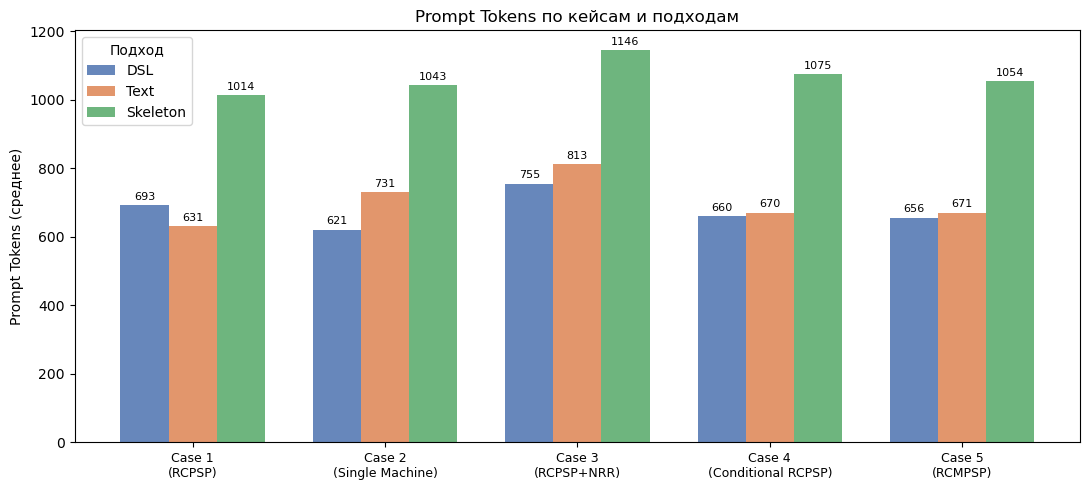

In [6]:
prompt_mean = df.groupby(['Подход', 'Кейс'])['Prompt'].mean().unstack(level=0).round(0)
prompt_mean = prompt_mean[['DSL', 'Text', 'Skeleton']]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(prompt_mean.index))
w = 0.25
for i, подход in enumerate(['DSL', 'Text', 'Skeleton']):
    bars = ax.bar(x + i*w, prompt_mean[подход], w, label=подход,
                  color=colors[подход], alpha=0.85)
    for bar, v in zip(bars, prompt_mean[подход]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{int(v)}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels([c.replace(' (', '\n(') for c in prompt_mean.index], fontsize=9)
ax.set_ylabel('Prompt Tokens (среднее)')
ax.set_title('Prompt Tokens по кейсам и подходам')
ax.legend(title='Подход')
plt.tight_layout()
plt.show()

Prompt tokens у Skeleton стабильно выше во всех кейсах по сравнению с DSL и Text примерно в 1.5 раза. Это фиксированная стоимость системного промпта, который содержит описание каркаса и структуру датаклассов, и не зависит от сложности конкретного кейса. DSL и Text имеют близкие значения prompt tokens между собой, при этом Text незначительно превышает DSL для Cases 2, 3 и 5.

## 4. Completion Tokens - объем генерируемого кода

Главный показатель диалог-стоимости. Отражает сложность и объем генерируемой эвристики. Имеет разброс между runs — модель каждый раз генерирует разный код.

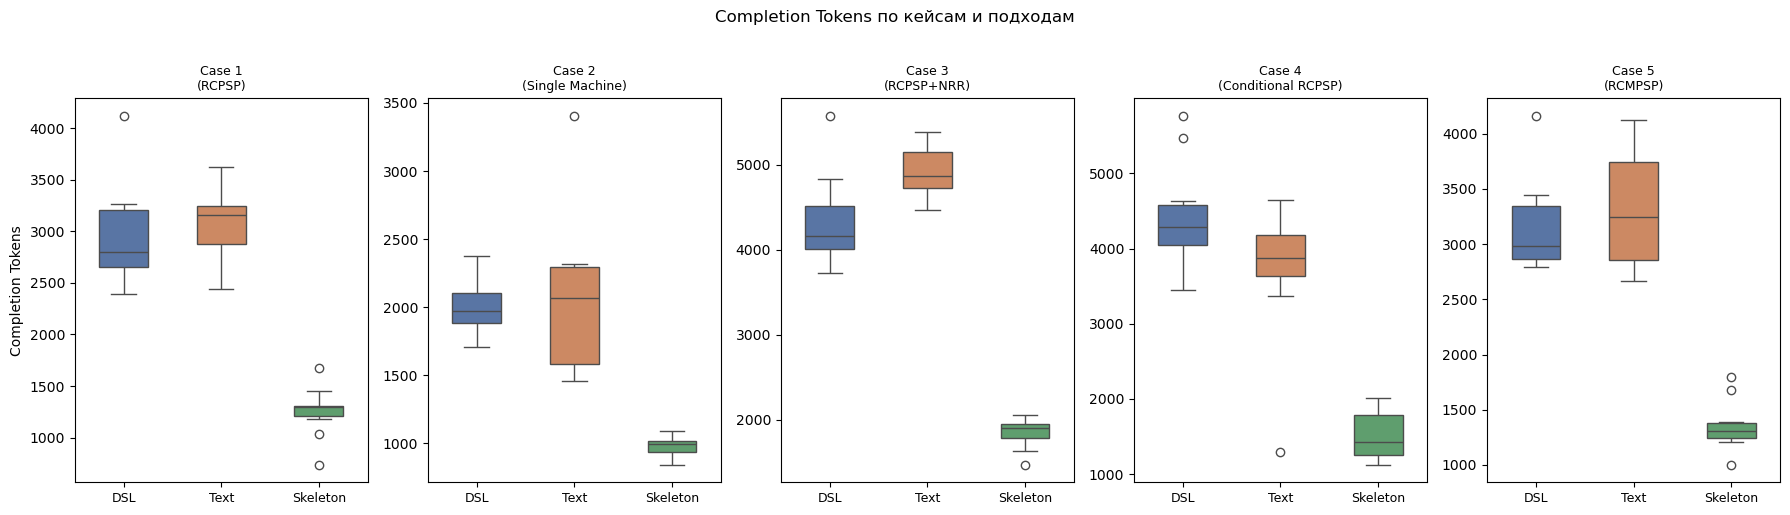

In [7]:
cases_list = sorted(df['Кейс'].unique())
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)

for ax, case in zip(axes, cases_list):
    data = df[df['Кейс'] == case]
    sns.boxplot(data=data, x='Подход', y='Completion', order=['DSL', 'Text', 'Skeleton'],
                palette=colors, ax=ax, width=0.5)
    ax.set_title(case.replace(' (', '\n('), fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Completion Tokens' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Completion Tokens по кейсам и подходам', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Skeleton демонстрирует наименьший разброс completion tokens (узкие ящики) во всех кейсах. Модель стабильно генерирует код примерно одинакового объема от запуска к запуску. DSL и Text имеют значительно больший разброс, особенно для Cases 3 и 4 (условное планирование), где Text показывает наибольшую нестабильность.

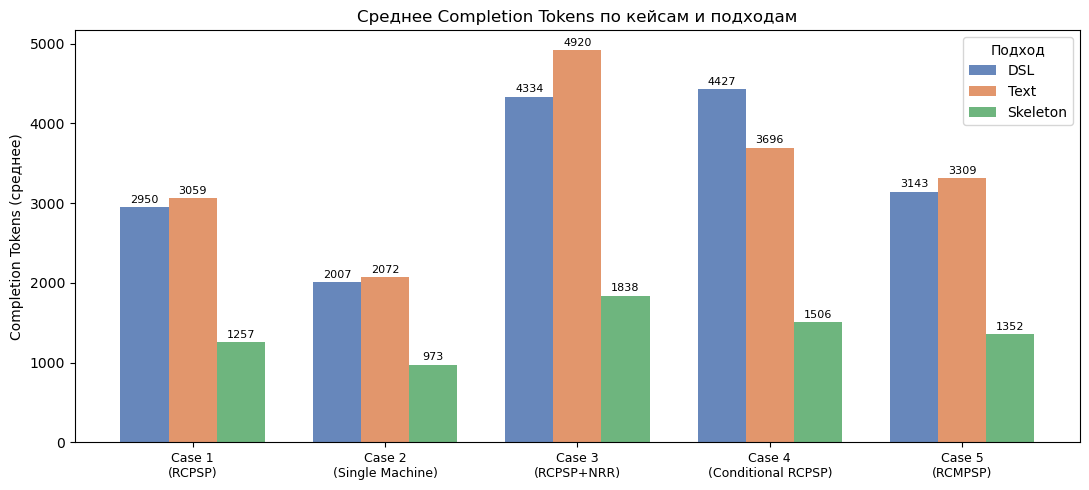

In [8]:
completion_mean = df.groupby(['Подход', 'Кейс'])['Completion'].mean().unstack(level=0).round(0)
completion_mean = completion_mean[['DSL', 'Text', 'Skeleton']]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(completion_mean.index))
w = 0.25
for i, подход in enumerate(['DSL', 'Text', 'Skeleton']):
    bars = ax.bar(x + i*w, completion_mean[подход], w, label=подход,
                  color=colors[подход], alpha=0.85)
    for bar, v in zip(bars, completion_mean[подход]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{int(v)}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels([c.replace(' (', '\n(') for c in completion_mean.index], fontsize=9)
ax.set_ylabel('Completion Tokens (среднее)')
ax.set_title('Среднее Completion Tokens по кейсам и подходам')
ax.legend(title='Подход')
plt.tight_layout()
plt.show()

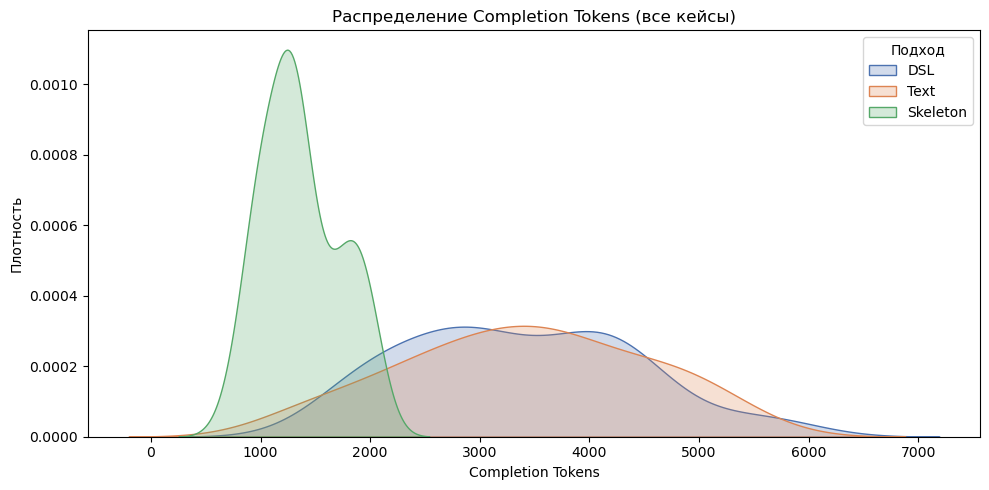

Completion Tokens (все кейсы):


,mean,median,std
Подход,,,
DSL,3372.0,3245.0,1040.0
Skeleton,1366.0,1300.0,352.0
Text,3411.0,3440.0,1091.0


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for подход in ['DSL', 'Text', 'Skeleton']:
    data = df[df['Подход'] == подход]['Completion']
    sns.kdeplot(data, ax=ax, label=подход, color=colors[подход], fill=True, alpha=0.25)

ax.set_xlabel('Completion Tokens')
ax.set_ylabel('Плотность')
ax.set_title('Распределение Completion Tokens (все кейсы)')
ax.legend(title='Подход')
plt.tight_layout()
plt.show()

print("Completion Tokens (все кейсы):")
df.groupby('Подход')['Completion'].agg(['mean','median','std']).round(0)

Распределения DSL и Text практически совпадают, они сосредоточены в диапазоне от 2000 до 5000 токенов со схожими средними (3372 и 3411) и стандартными отклонениями (1040 и 1091). Skeleton отличается: распределение сдвинуто влево и сконцентрировано в диапазоне от 1000 до 2000 токенов, среднее в 2.5 раза меньше (1366), стандартное отклонение втрое ниже (352). Это наглядно подтверждает что Skeleton не просто экономит токены, но и делает генерацию предсказуемой.

## 5. Вариативность между runs

Completion tokens меняются от run к run, модель генерирует разный по длине код. Высокая вариативность указывает на нестабильность генерации.

In [13]:
cv = df.groupby(['Подход', 'Кейс'])['Completion'].agg(
    lambda x: x.std() / x.mean() * 100).unstack(level=0).round(1)
cv = cv[['DSL', 'Text', 'Skeleton']]
print("Коэффициент вариации Completion Tokens (%, меньше = стабильнее):")
cv

Коэффициент вариации Completion Tokens (%, меньше = стабильнее):


Подход,DSL,Text,Skeleton
Кейс,,,
Case 1 (RCPSP),17.6,12.8,19.6
Case 2 (Single Machine),11.1,28.1,7.3
Case 3 (RCPSP+NRR),12.5,6.0,10.5
Case 4 (Conditional RCPSP),16.0,24.9,20.4
Case 5 (RCMPSP),13.7,16.2,17.0


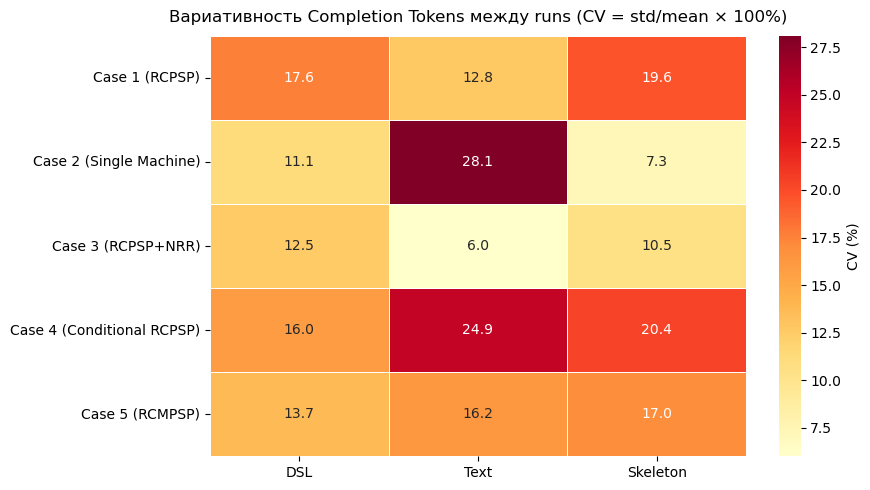

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(cv, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'CV (%)'})
ax.set_title('Вариативность Completion Tokens между runs (CV = std/mean × 100%)', pad=10)
ax.set_xlabel('')
ax.set_ylabel('')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Skeleton демонстрирует лучшую стабильность в критически важных кейсах:

1. Лучший результат в Case 2 (Single Machine) — 7.3% против 28.1% у Text и 11.1% у DSL. Это показывает, что Skeleton особенно эффективен для простых, детерминированных задач.

2. Отсутствие экстремальной нестабильности: максимальный CV у Skeleton = 20.4%, тогда как Text достигает 28.1%. Skeleton не имеет "провалов" — все значения в разумных пределах.

3. Средний CV по всем кейсам: 
   - Skeleton: **15.0%**
   - DSL: 14.2% 
   - Text: 17.6%

## 7. Выводы



1. Skeleton сокращает диалог-стоимость

Среднее completion tokens у Skeleton в 2.5 раза меньше чем у DSL и Text. Экономия составляет 51–66% в зависимости от кейса. Это прямое следствие архитектурного решения: модель генерирует только две небольшие функции вместо полного алгоритма планирования.

2. Сложность задачи влияет на DSL и Text, но не на Skeleton

Для DSL и Text completion tokens растет с увеличением сложности постановки, а именно от примерно 2 000 для Case 2 до 4300–4900 для Cases 3 и 4. Skeleton остается в диапазоне 973–1838 независимо от кейса.

3. Skeleton стабильнее по объему генерации

Стандартное отклонение completion у Skeleton втрое меньше чем у DSL и Text. Это объясняет более высокую надежность Skeleton: предсказуемый и малый объем генерации снижает вероятность обрезки ответа и синтаксических ошибок от лимита токенов.

4. Компромисс prompt tokens

Skeleton платит за экономию completion увеличенным промптом из-за описания каркаса в системном промпте. Однако это фиксированная и не зависящая от кейса стоимость, которая полностью компенсируется экономией на выходных токенах.